# Serie de Tiempo — Total Mensual de Viajeros Internacionales


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm
from prophet import Prophet
from IPython.display import Markdown, display

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga y preparación de datos

In [2]:
# Leer el CSV con el detalle de viajeros
df = pd.read_csv('./Base_Migracion_2009-2026jun.csv')
print('Shape del dataset:', df.shape)
print('\nColumnas:', list(df.columns))

Shape del dataset: (161036, 13)

Columnas: ['Año', 'Mes cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región', 'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia', 'Tipo de Viajero', 'Viajero']


In [3]:
# Construir la serie mensual: total de viajeros internacionales, sumando TODAS las vías,
# todos los países/regiones y todos los tipos de viajero (Turista, Excursionista, etc.)
total_mensual = df.groupby(['Año', 'Mes cod'])['Viajero'].sum().reset_index()

total_mensual['Fecha'] = pd.to_datetime(
    total_mensual['Año'].astype(str) + '-' + total_mensual['Mes cod'].astype(str).str.zfill(2) + '-01'
)

s = total_mensual[['Fecha', 'Viajero']].copy().set_index('Fecha').sort_index()
s = s.asfreq('MS')  # Frecuencia Mensual Start
n_huecos = s['Viajero'].isna().sum()
s = s.ffill()
s.columns = ['Total']

print(f'Inicio:      {s.index.min().strftime("%Y-%m")}')
print(f'Fin:         {s.index.max().strftime("%Y-%m")}')
print(f'Frecuencia:  Mensual (12 observaciones por año)')
print(f'Total obs:   {len(s)}')
print(f'Meses rellenados con ffill: {n_huecos}')

Inicio:      2009-01
Fin:         2026-06
Frecuencia:  Mensual (12 observaciones por año)
Total obs:   210
Meses rellenados con ffill: 0


### División en entrenamiento (~70%) y prueba (~30%)

In [4]:
train_size = int(len(s) * 0.7)
ts_train = s['Total'].iloc[:train_size]
ts_test = s['Total'].iloc[train_size:]

print(f'Train: {len(ts_train)} obs ({ts_train.index.min().strftime("%Y-%m")} a {ts_train.index.max().strftime("%Y-%m")})')
print(f'Test:  {len(ts_test)} obs ({ts_test.index.min().strftime("%Y-%m")} a {ts_test.index.max().strftime("%Y-%m")})')

Train: 147 obs (2009-01 a 2021-03)
Test:  63 obs (2021-04 a 2026-06)


In [5]:
def calcular_metricas(actual, predicho):
    """Calcula MAE y RMSE para arrays alineados"""
    actual_np = np.array(actual)
    pred_np = np.array(predicho)
    mask = ~np.isnan(actual_np) & ~np.isnan(pred_np)
    if not np.any(mask):
        return np.nan, np.nan
    mae = mean_absolute_error(actual_np[mask], pred_np[mask])
    rmse = np.sqrt(mean_squared_error(actual_np[mask], pred_np[mask]))
    return mae, rmse

---

### a) Inicio, fin, frecuencia, gráfico e interpretación

Inicio: 2009-01  |  Fin: 2021-03  |  Frecuencia: mensual  |  N observaciones (train): 147


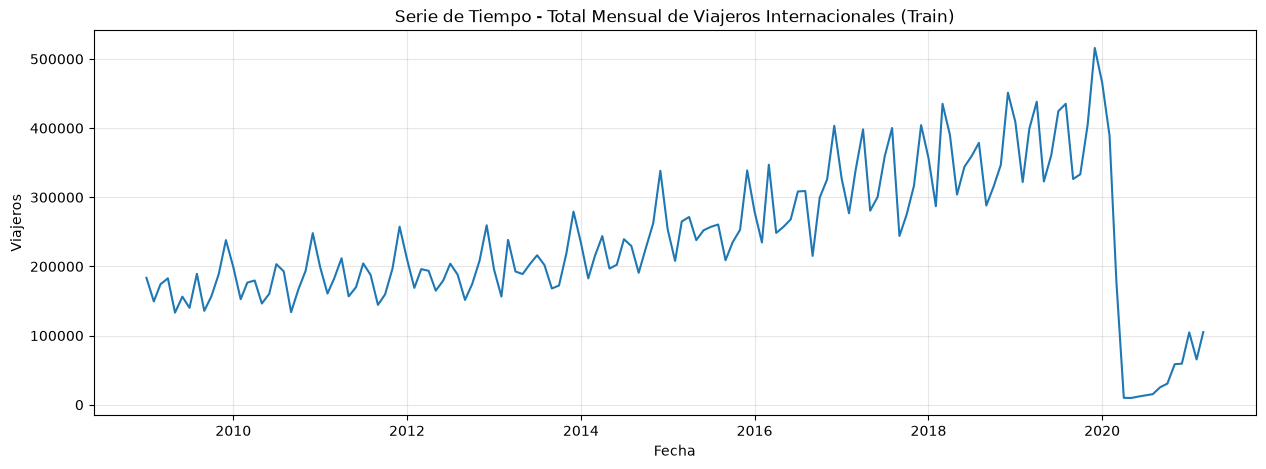

In [6]:
print(f"Inicio: {ts_train.index.min().strftime('%Y-%m')}  |  Fin: {ts_train.index.max().strftime('%Y-%m')}  |  "
      f"Frecuencia: mensual  |  N observaciones (train): {len(ts_train)}")

plt.figure(figsize=(15, 5))
plt.plot(ts_train)
plt.title('Serie de Tiempo - Total Mensual de Viajeros Internacionales (Train)')
plt.xlabel('Fecha')
plt.ylabel('Viajeros')
plt.grid(True, alpha=0.3)
plt.show()

### b) Descomposición: ¿estacionaria en media y en varianza?

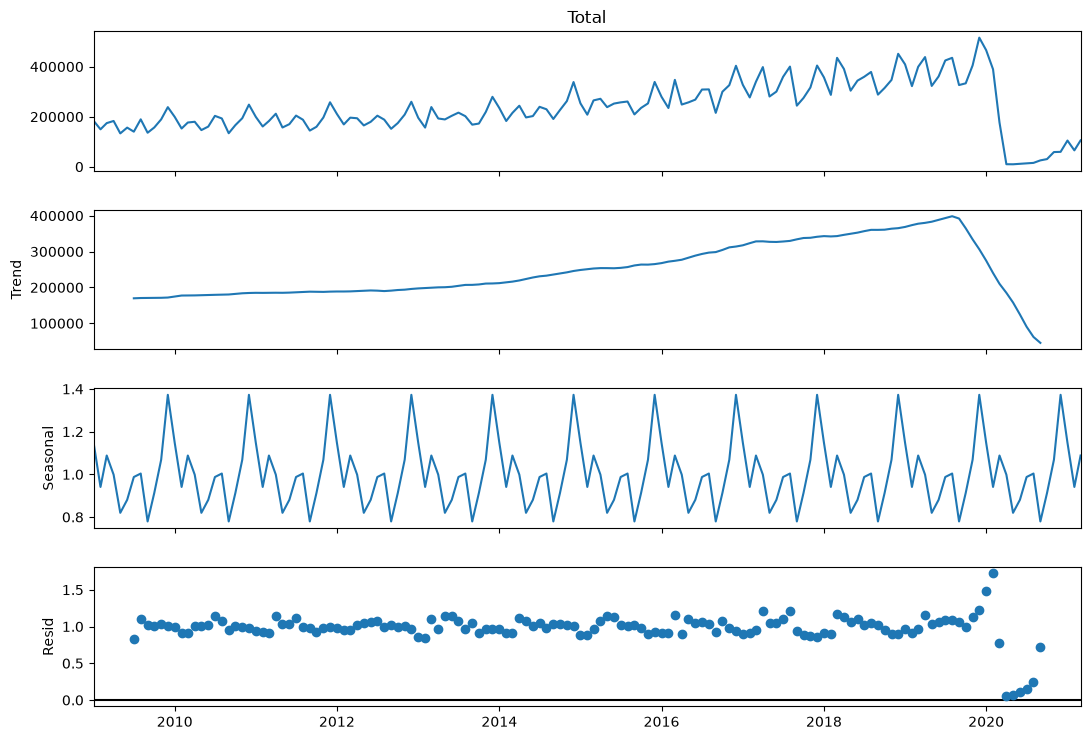

In [7]:
decomp_total = seasonal_decompose(ts_train, model='multiplicative', period=12)
decomp_total.plot()
plt.gcf().set_size_inches(12, 8)
plt.show()

### c) / d) ¿Es necesario transformar la serie? Explique.

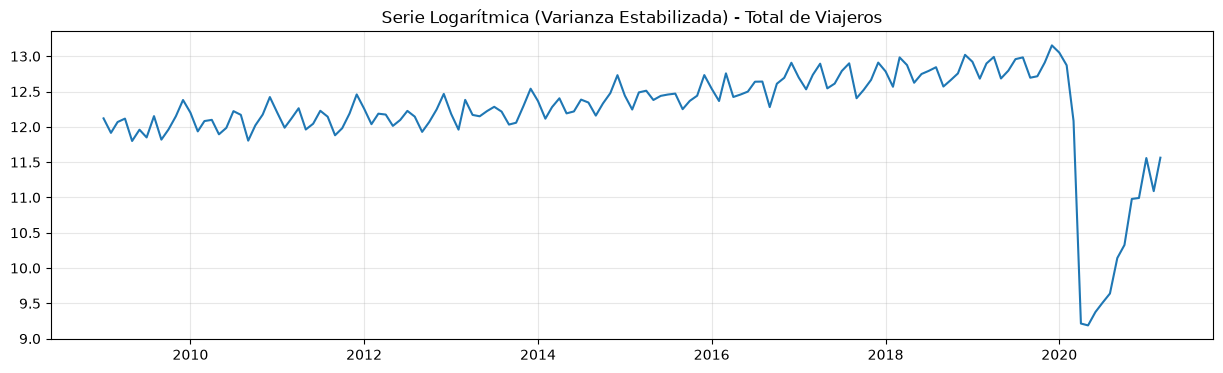

In [8]:
# Previniendo log(0) sumando una constante pequeña si hay ceros
ts_log = np.log(ts_train.replace(0, 1))

plt.figure(figsize=(15, 4))
plt.plot(ts_log)
plt.title('Serie Logarítmica (Varianza Estabilizada) - Total de Viajeros')
plt.grid(True, alpha=0.3)
plt.show()

### e.i) Gráfico de autocorrelación de la serie sin diferenciar

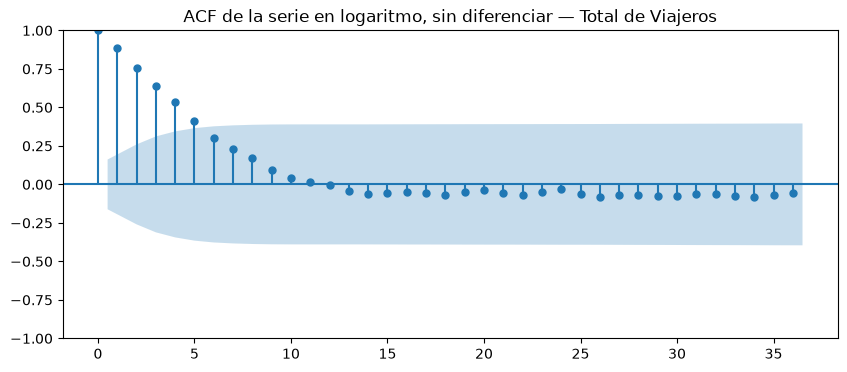

In [9]:
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(ts_log, lags=36, ax=ax)
ax.set_title('ACF de la serie en logaritmo, sin diferenciar — Total de Viajeros')
plt.show()

### e.ii) Corroboración con la prueba de Dickey-Fuller Aumentada (ADF)

In [22]:
# Test ADF en d=0 (sin diferenciar) — se revisa primero antes de decidir si hace falta diferenciar
adf_result_0 = adfuller(ts_log.dropna())
print('--- ADF en la serie en logaritmo, sin diferenciar (d=0) ---')
print(f'Estadístico ADF: {adf_result_0[0]:.4f}')
print(f'p-value:         {adf_result_0[1]:.4f}')
for k, v in adf_result_0[4].items():
    print(f'  Valor crítico {k}: {v:.4f}')

d_adf_total = 0 if adf_result_0[1] <= 0.05 else 1


--- ADF en la serie en logaritmo, sin diferenciar (d=0) ---
Estadístico ADF: -2.2356
p-value:         0.1936
  Valor crítico 1%: -3.4801
  Valor crítico 5%: -2.8834
  Valor crítico 10%: -2.5784


In [23]:
d_opt_total = 1 if d_adf_total == 0 else d_adf_total

ts_diff_check = ts_log.diff(d_opt_total).dropna()
adf_result_1 = adfuller(ts_diff_check)
print(f'd_opt final usado para la serie Total: {d_opt_total}')
print(f'\n--- ADF después de diferenciar una vez (d={d_opt_total}) ---')
print(f'Estadístico ADF: {adf_result_1[0]:.4f}')
print(f'p-value:         {adf_result_1[1]:.4f}')


d_opt final usado para la serie Total: 1

--- ADF después de diferenciar una vez (d=1) ---
Estadístico ADF: -3.1003
p-value:         0.0265


### f) Selección de p, d, q con base en ACF/PACF, y validación con `auto_arima`

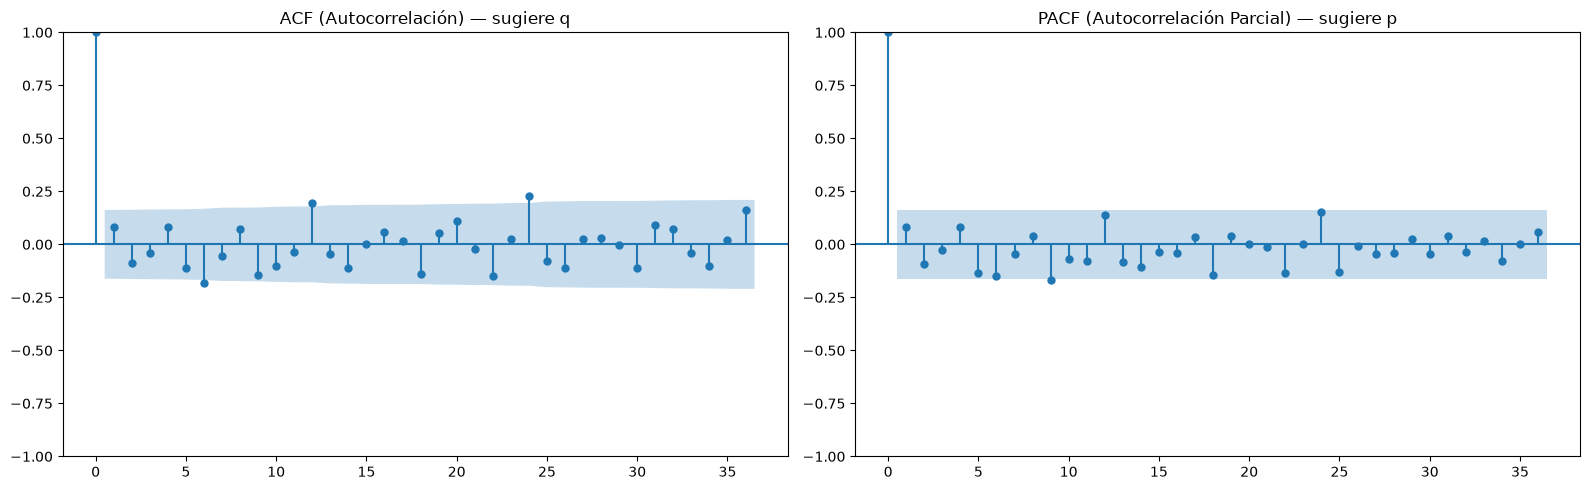

In [12]:
ts_estacionaria_total = ts_log.diff(d_opt_total).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_estacionaria_total, lags=36, ax=axes[0])
axes[0].set_title('ACF (Autocorrelación) — sugiere q')
plot_pacf(ts_estacionaria_total, lags=36, ax=axes[1], method='ywm')
axes[1].set_title('PACF (Autocorrelación Parcial) — sugiere p')
plt.tight_layout()
plt.show()

In [13]:
print('Buscando el mejor modelo SARIMA para el Total de Viajeros...')
auto_model_total = pm.auto_arima(ts_log,
                              seasonal=True, m=12,
                              d=d_opt_total, D=1,
                              max_p=3, max_q=3, max_P=2, max_Q=2,
                              trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)

print('\nResumen del mejor modelo encontrado por auto_arima:')
print(auto_model_total.summary())

Buscando el mejor modelo SARIMA para el Total de Viajeros...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=67.073, Time=0.44 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=88.271, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=75.146, Time=0.05 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=74.631, Time=0.07 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=67.510, Time=0.45 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=69.940, Time=0.29 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=73.621, Time=0.61 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=inf, Time=0.54 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=inf, Time=0.14 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=67.970, Time=0.52 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=69.907, Time=0.41 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=inf, Time=0.61 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=69.188, Time=0.38 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=71.461, Time=0.29

### g) Varios modelos ARIMA/SARIMA — comparación de residuos, AIC y BIC

In [14]:
p_t, d_t, q_t = auto_model_total.order
P_t, D_t, Q_t, s_t = auto_model_total.seasonal_order

candidatos_total = [
    {'nombre': 'Candidato 1 (auto_arima)', 'order': (p_t, d_t, q_t), 'seasonal_order': (P_t, D_t, Q_t, s_t)},
    {'nombre': 'Candidato 2 (AR adicional)', 'order': (min(p_t + 1, 3), d_t, q_t), 'seasonal_order': (P_t, D_t, Q_t, s_t)},
    {'nombre': 'Candidato 3 (parsimonioso)', 'order': (1, d_t, 1), 'seasonal_order': (0, D_t, 1, s_t)},
]

resultados_total = []
for cand in candidatos_total:
    try:
        modelo_fit = SARIMAX(ts_log, order=cand['order'], seasonal_order=cand['seasonal_order'],
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=100)
        resultados_total.append({**cand, 'aic': modelo_fit.aic, 'bic': modelo_fit.bic, 'modelo': modelo_fit})
    except Exception as e:
        print(f"No se pudo ajustar {cand['nombre']}: {e}")

tabla_candidatos_total = pd.DataFrame([
    {'Modelo': r['nombre'], 'Orden': f"{r['order']}x{r['seasonal_order']}",
      'AIC': round(r['aic'], 2), 'BIC': round(r['bic'], 2)}
    for r in resultados_total
])
display(Markdown(tabla_candidatos_total.to_markdown(index=False)))

mejor_arima_total = min(resultados_total, key=lambda r: r['aic'])
print(f"\n=> Mejor modelo ARIMA/SARIMA por AIC: {mejor_arima_total['nombre']} "
      f"{mejor_arima_total['order']}x{mejor_arima_total['seasonal_order']} "
      f"(AIC={mejor_arima_total['aic']:.2f}, BIC={mejor_arima_total['bic']:.2f})")

| Modelo                     | Orden                   |   AIC |   BIC |
|:---------------------------|:------------------------|------:|------:|
| Candidato 1 (auto_arima)   | (2, 1, 2)x(1, 1, 1, 12) | 67.96 | 87.42 |
| Candidato 2 (AR adicional) | (3, 1, 2)x(1, 1, 1, 12) | 69.76 | 91.99 |
| Candidato 3 (parsimonioso) | (1, 1, 1)x(0, 1, 1, 12) | 76.43 | 87.58 |


=> Mejor modelo ARIMA/SARIMA por AIC: Candidato 1 (auto_arima) (2, 1, 2)x(1, 1, 1, 12) (AIC=67.96, BIC=87.42)


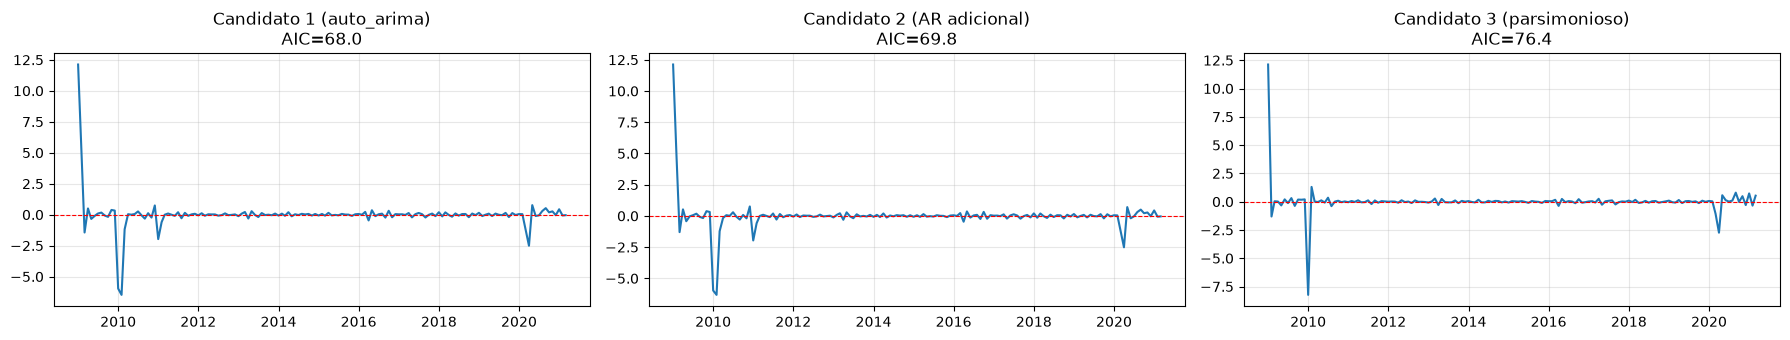

In [15]:
fig, axes = plt.subplots(1, len(resultados_total), figsize=(6*len(resultados_total), 3.5))
for ax, r in zip(axes, resultados_total):
    ax.plot(r['modelo'].resid)
    ax.set_title(f"{r['nombre']}\nAIC={r['aic']:.1f}")
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

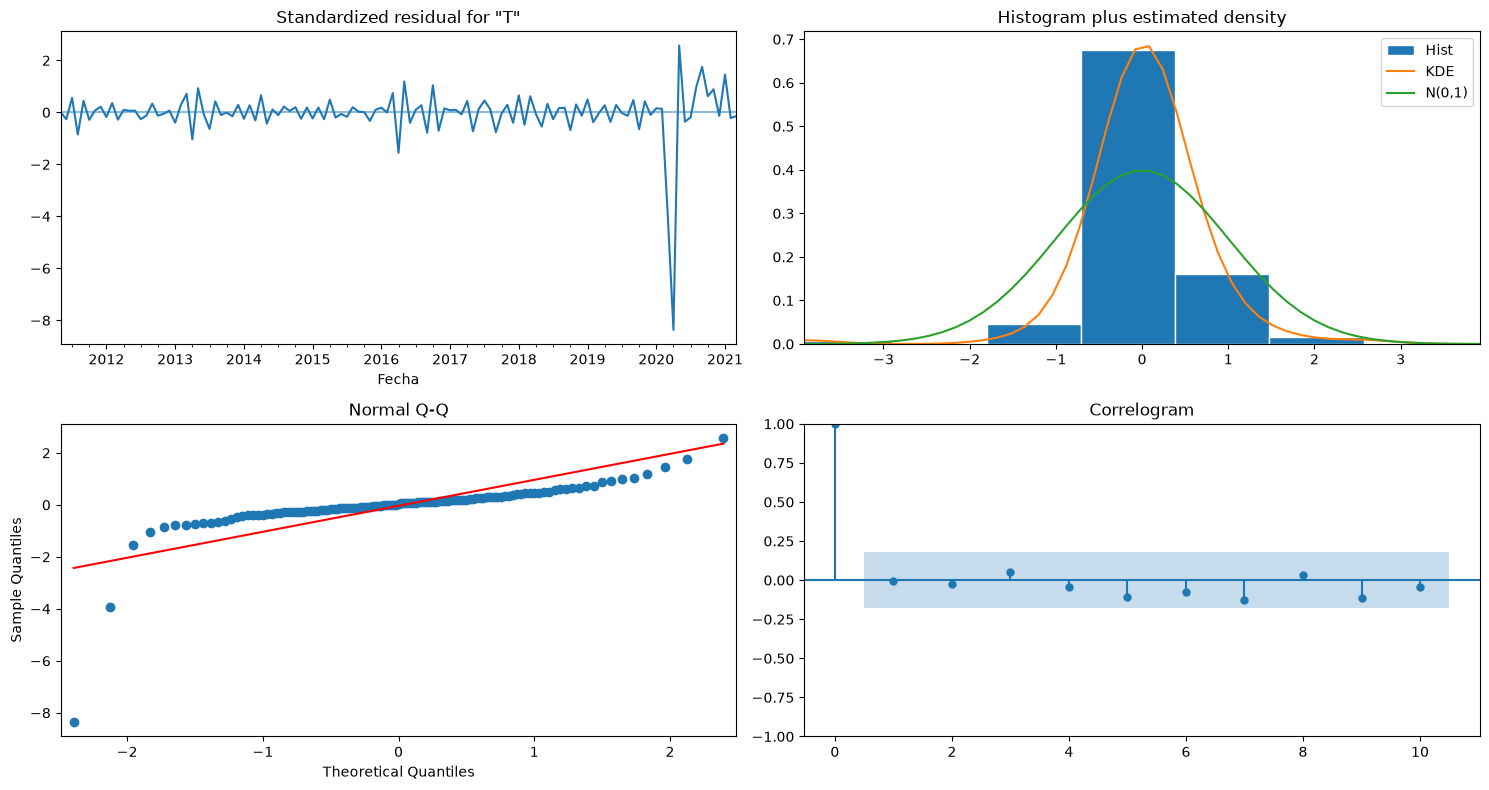

In [16]:
mejor_arima_total['modelo'].plot_diagnostics(figsize=(15, 8))
plt.tight_layout()
plt.show()

### h) Modelos alternativos — Prophet, Holt-Winters y Seasonal Naive

In [17]:
test_ts_total = ts_test
n_test_total = len(test_ts_total)

# 1. Predicción ARIMA/SARIMA (mejor modelo del inciso g, convertido de logaritmo a escala original)
pred_log_arima = mejor_arima_total['modelo'].get_forecast(steps=n_test_total).predicted_mean
pred_arima_total = np.exp(pred_log_arima)
pred_arima_total.index = test_ts_total.index

# 2. Holt-Winters
hw_model_total = ExponentialSmoothing(ts_train, trend='mul', seasonal='mul', seasonal_periods=12).fit(optimized=True)
pred_hw_total = hw_model_total.forecast(n_test_total)

# 3. Seasonal Naive
last_year_total = ts_train.iloc[-12:].values
pred_snaive_vals_total = np.tile(last_year_total, int(np.ceil(n_test_total / 12.0)))[:n_test_total]
pred_snaive_total = pd.Series(pred_snaive_vals_total, index=test_ts_total.index)

# 4. Prophet
prophet_df_total = pd.DataFrame({'ds': ts_train.index, 'y': ts_train.values})
m_prophet_total = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_prophet_total.fit(prophet_df_total)
future_total = m_prophet_total.make_future_dataframe(periods=n_test_total, freq='MS')
forecast_total = m_prophet_total.predict(future_total)
pred_prophet_total = forecast_total.set_index('ds')['yhat'].iloc[-n_test_total:]

print('Modelos alternativos ajustados y predicciones generadas.')

22:22:12 - cmdstanpy - INFO - Chain [1] start processing
22:22:12 - cmdstanpy - INFO - Chain [1] done processing


Modelos alternativos ajustados y predicciones generadas.


### i) Predicción de los valores de la serie en el conjunto de prueba

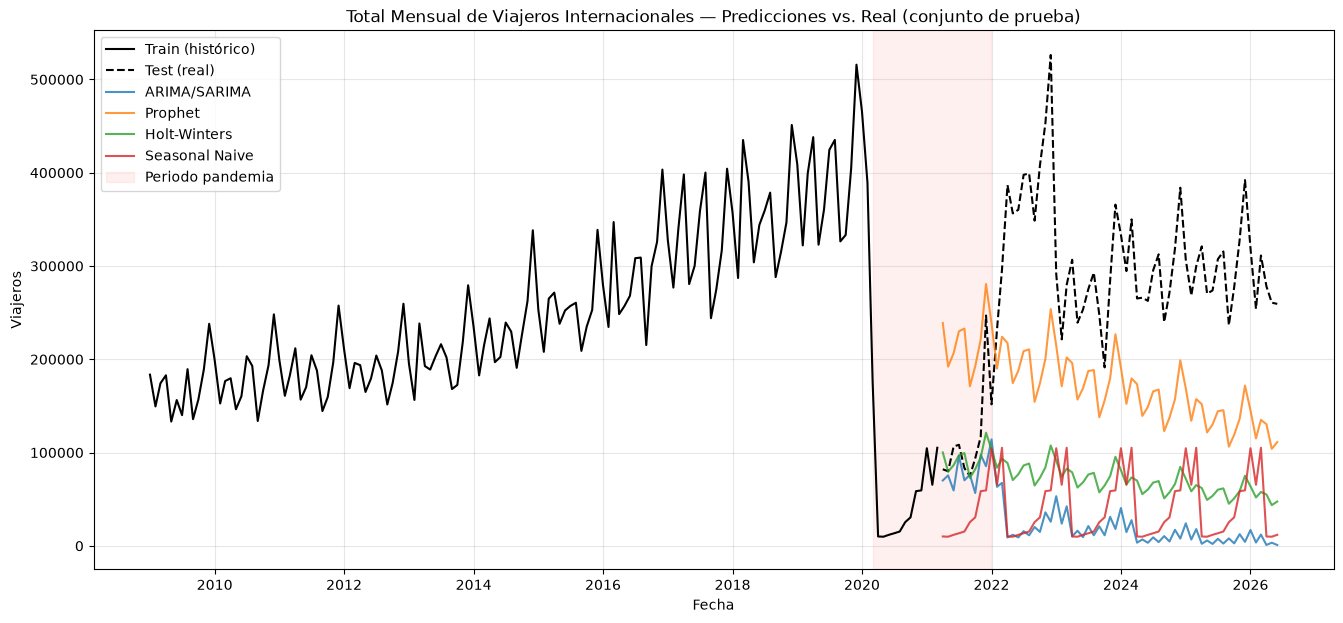

In [18]:
plt.figure(figsize=(16, 7))
plt.plot(ts_train.index, ts_train, label='Train (histórico)', color='black')
plt.plot(test_ts_total.index, test_ts_total, label='Test (real)', color='black', linestyle='--')
plt.plot(pred_arima_total.index, pred_arima_total, label='ARIMA/SARIMA', alpha=0.8)
plt.plot(pred_prophet_total.index, pred_prophet_total, label='Prophet', alpha=0.8)
plt.plot(pred_hw_total.index, pred_hw_total, label='Holt-Winters', alpha=0.8)
plt.plot(pred_snaive_total.index, pred_snaive_total, label='Seasonal Naive', alpha=0.8)
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'), color='red', alpha=0.06, label='Periodo pandemia')
plt.title('Total Mensual de Viajeros Internacionales — Predicciones vs. Real (conjunto de prueba)')
plt.xlabel('Fecha')
plt.ylabel('Viajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### j) Comparación de modelos mediante MAE, RMSE, AIC y BIC

In [19]:
metricas_total = []

m_arima = calcular_metricas(test_ts_total, pred_arima_total)
m_prophet_m = calcular_metricas(test_ts_total, pred_prophet_total)
m_hw = calcular_metricas(test_ts_total, pred_hw_total)
m_snaive = calcular_metricas(test_ts_total, pred_snaive_total)

aic_arima = mejor_arima_total['aic']
bic_arima = mejor_arima_total['bic']

metricas_total.append(['ARIMA/SARIMA', round(m_arima[0], 2), round(m_arima[1], 2), round(aic_arima, 2), round(bic_arima, 2)])
metricas_total.append(['Prophet', round(m_prophet_m[0], 2), round(m_prophet_m[1], 2), '—', '—'])
metricas_total.append(['Holt-Winters', round(m_hw[0], 2), round(m_hw[1], 2), '—', '—'])
metricas_total.append(['Seasonal Naive', round(m_snaive[0], 2), round(m_snaive[1], 2), '—', '—'])

df_res_total = pd.DataFrame(metricas_total, columns=['Modelo', 'MAE', 'RMSE', 'AIC', 'BIC'])
display(Markdown(df_res_total.to_markdown(index=False)))

| Modelo         |    MAE |   RMSE | AIC   | BIC   |
|:---------------|-------:|-------:|:------|:------|
| ARIMA/SARIMA   | 250720 | 274280 | 67.96 | 87.42 |
| Prophet        | 136571 | 144939 | —     | —     |
| Holt-Winters   | 204883 | 224809 | —     | —     |
| Seasonal Naive | 235731 | 253203 | —     | —     |

### k) Selección del mejor modelo

In [ ]:
mejor_modelo_idx_total = df_res_total['RMSE'].astype(float).idxmin()
mejor_modelo_nombre_total = df_res_total.iloc[mejor_modelo_idx_total]['Modelo']

mejor_por_mae_total = df_res_total.iloc[df_res_total['MAE'].astype(float).idxmin()]['Modelo']
coincide = "sí" if mejor_por_mae_total == mejor_modelo_nombre_total else "no"

print(f"=> Modelo seleccionado para el Total de Viajeros (menor RMSE): {mejor_modelo_nombre_total}")


=> Modelo seleccionado para el Total de Viajeros (menor RMSE): Prophet
   (Por MAE el ganador sería: Prophet — ¿coincide con RMSE? sí)
